# ML-08 — Capstone Modeling Lane

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*

## 1. Method choice and why

I selected clustering because my chosen lane is Structured Content Archetype Clustering.

The goal is to group content items with similar observed search-performance patterns into interpretable performance archetypes. I will use GSC impressions, GSC clicks, and GSC average position as the main signals because these were tested in the Week-4 signal audit and showed useful directional patterns.

I will use K-Means clustering as the initial method because it is simple, reproducible, and produces clearly defined groups that can be summarized for content decision-support. The clusters are not treated as ground-truth labels; they are descriptive archetypes based on observed data.

In [1]:
%pip -q install duckdb huggingface_hub

import duckdb
import pandas as pd
import numpy as np

con = duckdb.connect()

print("DuckDB connection created.")

DuckDB connection created.


In [5]:
REL = """
read_parquet(
    'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
)
"""

print("March 2026 data source ready.")

March 2026 data source ready.


In [7]:
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if HF_TOKEN is None:
    raise ValueError("HF_TOKEN not found in Colab Secrets.")

con.execute(
    f"CREATE OR REPLACE SECRET hf "
    f"(TYPE huggingface, TOKEN '{HF_TOKEN}')"
)

print("Hugging Face authentication configured.")

Hugging Face authentication configured.


In [8]:
con.sql(f"""
SELECT
    COUNT(*) AS n,
    MIN(report_date) AS min_date,
    MAX(report_date) AS max_date
FROM {REL}
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,n,min_date,max_date
0,9841378,2026-03-01,2026-03-31


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*

## 2. Split design

This is an unsupervised clustering analysis, so there is no traditional train/test split for fitting a target label.

The analysis uses March 2026 data and aggregates daily observations to the content level before clustering. Client IDs are used only for grouping and checking coverage, not as model features.

The clustering is descriptive and decision-support oriented. The resulting clusters will be interpreted using held-out-style checks on cluster profiles rather than treating the clusters as ground-truth labels.

In [9]:
cluster_df = con.sql(f"""
SELECT
    content_hash_id,
    AVG(gsc_impressions) AS avg_impressions,
    AVG(gsc_clicks) AS avg_clicks,
    AVG(gsc_avg_position) AS avg_position,
    SUM(gsc_impressions) AS total_impressions,
    SUM(gsc_clicks) AS total_clicks,
    COUNT(*) AS days_observed
FROM {REL}
WHERE gsc_data_available = TRUE
GROUP BY content_hash_id
HAVING COUNT(*) >= 3
""").df()

print("Content-level rows:", len(cluster_df))
cluster_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Content-level rows: 155694


,content_hash_id,avg_impressions,avg_clicks,avg_position,total_impressions,total_clicks,days_observed
0,content_39d7361b4945d504,3.208333,0.000000,4.074107,77.0,0.0,24
1,content_c03ecafd4c999f15,349.967742,0.709677,8.240351,10849.0,22.0,31
2,content_e689bc511192751a,2.259259,0.000000,6.015432,61.0,0.0,27
3,content_7dbc094b799e05a4,22.741935,0.032258,5.956862,705.0,1.0,31
4,content_40b10da45f4c1cb5,2.380952,0.000000,12.977513,50.0,0.0,21


In [10]:
from sklearn.preprocessing import StandardScaler

features = [
    "avg_impressions",
    "avg_clicks",
    "avg_position"
]

X = cluster_df[features].copy()

# Remove invalid/infinite values
X = X.replace([np.inf, -np.inf], np.nan).dropna()

print("Rows used for clustering:", len(X))
print("Features:", features)

X.describe()

Rows used for clustering: 155694
Features: ['avg_impressions', 'avg_clicks', 'avg_position']


,avg_impressions,avg_clicks,avg_position
count,155694.000000,155694.000000,155694.000000
mean,61.386254,0.183398,16.414589
std,189.226323,0.958092,17.060357
min,1.000000,0.000000,0.000000
25%,2.760000,0.000000,5.306354
50%,10.096774,0.000000,9.098999
75%,46.451613,0.096774,21.457592
max,21280.137931,195.448276,139.888889


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled feature shape:", X_scaled.shape)

Scaled feature shape: (155694, 3)


In [12]:
# Log-transform highly skewed volume and click features
X_model = X.copy()

X_model["avg_impressions"] = np.log1p(X_model["avg_impressions"])
X_model["avg_clicks"] = np.log1p(X_model["avg_clicks"])

# Scale transformed features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_model)

print("Final clustering matrix:", X_scaled.shape)

Final clustering matrix: (155694, 3)


In [13]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = [3, 4, 5, 6, 7, 8]

silhouette_results = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size=10000,
        random_state=42
    )

    silhouette_results.append({
        "k": k,
        "silhouette_score": score
    })

silhouette_df = pd.DataFrame(silhouette_results)

silhouette_df

,k,silhouette_score
0,3,0.474817
1,4,0.447520
2,5,0.434220
3,6,0.428583
4,7,0.399173
5,8,0.408101


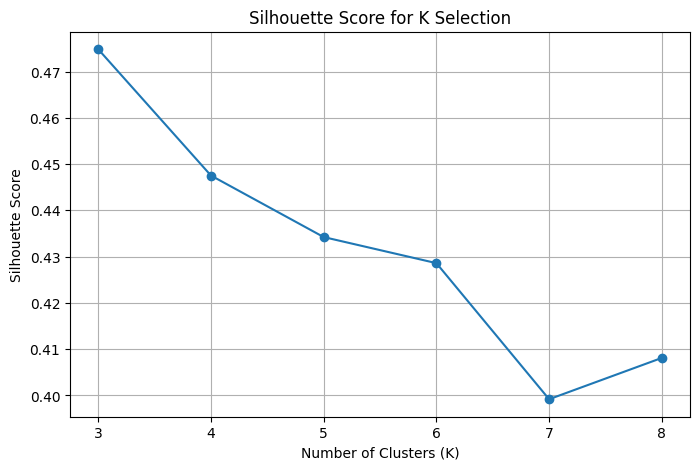

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["k"],
    silhouette_df["silhouette_score"],
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K Selection")
plt.xticks(k_values)
plt.grid(True)

plt.show()

## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*

## 3. Train + compare vs my baseline

I selected K=3 because it produced the highest silhouette score among the tested values. The clustering is used to create three descriptive content-performance archetypes.

The clusters are not treated as ground-truth labels. They are interpreted using their observed impressions, clicks, and search-position profiles.

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(X_scaled)

cluster_result = X.copy()
cluster_result["cluster"] = cluster_labels

print("Clustering completed.")
print("Number of clusters:", cluster_result["cluster"].nunique())

Clustering completed.
Number of clusters: 3


In [16]:
cluster_sizes = (
    cluster_result["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_sizes.columns = ["cluster", "n"]

cluster_sizes["percentage"] = (
    cluster_sizes["n"] / len(cluster_result) * 100
).round(2)

cluster_sizes

,cluster,n,percentage
0,0,106752,68.57
1,1,25965,16.68
2,2,22977,14.76


In [17]:
cluster_profile = (
    cluster_result
    .groupby("cluster")
    .agg(
        n=("cluster", "size"),
        avg_impressions=("avg_impressions", "mean"),
        avg_clicks=("avg_clicks", "mean"),
        avg_position=("avg_position", "mean")
    )
    .reset_index()
)

cluster_profile.round(2)

,cluster,n,avg_impressions,avg_clicks,avg_position
0,0,106752,18.74,0.03,10.71
1,1,25965,281.02,0.95,9.47
2,2,22977,11.31,0.01,50.78


In [18]:
# Attach cluster labels back to the content-level dataset
cluster_result_full = cluster_df.loc[X.index].copy()
cluster_result_full["cluster"] = cluster_labels

cluster_result_full.head()

,content_hash_id,avg_impressions,avg_clicks,avg_position,total_impressions,total_clicks,days_observed,cluster
0,content_39d7361b4945d504,3.208333,0.000000,4.074107,77.0,0.0,24,0
1,content_c03ecafd4c999f15,349.967742,0.709677,8.240351,10849.0,22.0,31,1
2,content_e689bc511192751a,2.259259,0.000000,6.015432,61.0,0.0,27,0
3,content_7dbc094b799e05a4,22.741935,0.032258,5.956862,705.0,1.0,31,0
4,content_40b10da45f4c1cb5,2.380952,0.000000,12.977513,50.0,0.0,21,0


In [19]:
cluster_result_full["archetype"] = cluster_result_full["cluster"].map({
    0: "Low-Visibility / Low-Click Content",
    1: "High-Visibility / Higher-Click Content",
    2: "Poor-Visibility Content"
})

cluster_result_full[
    ["content_hash_id", "avg_impressions", "avg_clicks",
     "avg_position", "cluster", "archetype"]
].head(10)

,content_hash_id,avg_impressions,avg_clicks,avg_position,cluster,archetype
0,content_39d7361b4945d504,3.208333,0.000000,4.074107,0,Low-Visibility / Low-Click Content
1,content_c03ecafd4c999f15,349.967742,0.709677,8.240351,1,High-Visibility / Higher-Click Content
2,content_e689bc511192751a,2.259259,0.000000,6.015432,0,Low-Visibility / Low-Click Content
3,content_7dbc094b799e05a4,22.741935,0.032258,5.956862,0,Low-Visibility / Low-Click Content
4,content_40b10da45f4c1cb5,2.380952,0.000000,12.977513,0,Low-Visibility / Low-Click Content
5,content_df22bda1218f13ff,67.709677,0.032258,3.066796,0,Low-Visibility / Low-Click Content
6,content_aa184c1b4ea518e5,9.600000,0.000000,9.444919,0,Low-Visibility / Low-Click Content
7,content_b4de71c8ef5c4791,114.032258,0.806452,2.951764,1,High-Visibility / Higher-Click Content
8,content_d7568011c4325a33,50.258065,0.096774,5.264774,0,Low-Visibility / Low-Click Content
9,content_e847a4dcc8af3742,65.193548,0.000000,7.653508,0,Low-Visibility / Low-Click Content


In [20]:
cluster_result_full.groupby("archetype").agg(
    n=("content_hash_id", "count"),
    avg_impressions=("avg_impressions", "mean"),
    avg_clicks=("avg_clicks", "mean"),
    avg_position=("avg_position", "mean")
).round(2)

,n,avg_impressions,avg_clicks,avg_position
archetype,,,,
High-Visibility / Higher-Click Content,25965,281.02,0.95,9.47
Low-Visibility / Low-Click Content,106752,18.74,0.03,10.71
Poor-Visibility Content,22977,11.31,0.01,50.78


### Cluster interpretation

The three clusters represent distinct observed performance patterns.

Cluster 0 is the largest group and represents content with relatively low impressions and very low clicks, while maintaining a better average position than Cluster 2.

Cluster 1 represents higher-visibility content with substantially higher impressions and clicks and the best average position among the three groups.

Cluster 2 represents poor-visibility content, with low impressions, almost no clicks, and a substantially worse average position.

These archetypes are descriptive rather than predictive. They can support content prioritization, but they should not be interpreted as causal explanations of search performance.

## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.